# Cumulative Return (run uuid 별 빠르게 보기)

이 노트북은 저장된 `ret.pkl`(AlphaAgent) 또는 `report_normal_1day.pkl`(01_15_new_qlib Stage4 artifacts)을 읽어서:

- **qlib 방식 누적수익률**: `cumsum(daily_return)`
- **복리(compound) 누적수익률**: `cumprod(1 + daily_return) - 1`

를 run uuid(=workspace uuid) 별로 표/그래프로 찍어봅니다.

### CSI500(Alpha158)

- LightGBM : /data-a/home_dgu/fin/qlib/examples/mlruns/319457791950376549/627770fb8e524f8bb874bb8d364dfcba
- Linear : /data-a/home_dgu/mlruns/430189588706002109/25740f7b954d4ff99c99e59e5f2145d4
- MLP : /data-a/home_dgu/mlruns/430189588706002109/82a4574e6bb9409f91774a525b190fa3
- Transformer : /data-a/home_dgu/mlruns/430189588706002109/9abe2ab89b1d47d5ae00ab4fa4a2ab7e
- XGBoost : /data-a/home_dgu/mlruns/430189588706002109/48d720298d57429bbbcf05984eb70158

- Ours: "/home/dgu/fin/01_15_new_qlib/runs/20260206_142717/qlib_artifacts/iter_4/combo_10/oos/report_normal_1day.pkl", (MDD 크면서 성능도 좋다 ~ 근데 사실 이때 IR 별로 안큼)
- "Ours": "/home/dgu/fin/01_15_new_qlib/runs/20260206_142717/qlib_artifacts/iter_5/combo_42/oos/report_normal_1day.pkl",



### SP500(Alpha158)

- LightGBM : /data-a/home_dgu/mlruns/430189588706002109/e32fe820378c4b17ba0f538f98c803bd
- Linear : /data-a/home_dgu/mlruns/430189588706002109/22520a8aebdd447a83138a6237fafb4d
- MLP : /data-a/home_dgu/mlruns/430189588706002109/8d729d2f97f44dd2a8f5b62bf8bba10f
- Transformer : /data-a/home_dgu/mlruns/430189588706002109/dbba216ee2244931a232c8514fb2381e
- XGBoost : /data-a/home_dgu/mlruns/430189588706002109/b29ad6acff344554a084278b115998b3

In [39]:
from __future__ import annotations

import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

def _safe_read_pickle(p):
    """pd.read_pickle wrapper that tolerates NumPy 2.x pickles (numpy._core) in NumPy 1.x envs."""
    try:
        return pd.read_pickle(p)
    except ModuleNotFoundError as e:
        if "numpy._core" not in str(e):
            raise
        import numpy.core as npcore
        import sys

        sys.modules.setdefault("numpy._core", npcore)
        try:
            import numpy.core._multiarray_umath as mau

            sys.modules.setdefault("numpy._core._multiarray_umath", mau)
        except Exception:
            pass
        return pd.read_pickle(p)

# --- project root 찾기 (run.cumulative_return import용) ---
CWD = Path.cwd().resolve()
if CWD.name == "analysis" and (CWD / "cum_return.ipynb").exists():
    PROJECT_ROOT = CWD.parent
else:
    PROJECT_ROOT = None
    cur = CWD
    for _ in range(6):
        if (cur / "run").is_dir() and (cur / "runs").is_dir():
            PROJECT_ROOT = cur
            break
        cur = cur.parent
    if PROJECT_ROOT is None:
        PROJECT_ROOT = CWD

sys.path.insert(0, str(PROJECT_ROOT))
from run.cumulative_return import _compute_curves  # noqa: E402

PROJECT_ROOT

PosixPath('/home/dgu/fin/01_15_new_qlib')

In [40]:
# ---------- AlphaAgent results(ret.pkl) 스캔 ----------
ALPHAAGENT_RESULTS_ROOT = Path("/home/dgu/fin/AlphaAgent/results")
MAX_FILES = 200  # 너무 많으면 느려서 상한 둠


def find_alphaagent_ret_pkls(results_root: Path, *, max_files: int = 200) -> list[Path]:
    if not results_root.exists():
        return []
    pkls = list(results_root.glob("*/backtest/*/ret.pkl"))
    pkls.sort(key=lambda p: p.stat().st_mtime if p.exists() else 0, reverse=True)
    return pkls[:max_files]


ret_pkls = find_alphaagent_ret_pkls(ALPHAAGENT_RESULTS_ROOT, max_files=MAX_FILES)
len(ret_pkls), ret_pkls[:3]

(49,
 [PosixPath('/home/dgu/fin/AlphaAgent/results/2026-02-03_17-23-06-199838/backtest/86b8bc240c0146b1a831aca44bad4728/ret.pkl'),
  PosixPath('/home/dgu/fin/AlphaAgent/results/2026-02-03_17-23-06-199838/backtest/f8db09233bd141db8981d22f0a98cd03/ret.pkl'),
  PosixPath('/home/dgu/fin/AlphaAgent/results/2026-02-03_17-23-06-199838/backtest/6448fa1306a7408494e177ccfa5bff17/ret.pkl')])

In [41]:
import re

CONF_ROOTS = [
    Path("/home/dgu/fin/AlphaAgent/git_ignore_folder/RD-Agent_workspace"),
    Path("/home/dgu/fin/RD-Agent/git_ignore_folder/RD-Agent_workspace"),
    Path("/home/dgu/fin/git_ignore_folder/RD-Agent_workspace"),
]


def _strip_comment(v: str) -> str:
    return v.split("#", 1)[0].strip()


def _yaml_first_value(text: str, key: str) -> str | None:
    # naive YAML parse: first occurrence of "key: value" (ignores nested structure)
    # supports anchors like "market: &market csi500".
    pat = re.compile(rf"^\s*{re.escape(key)}\s*:\s*(.+?)\s*$", re.M)
    m = pat.search(text)
    if not m:
        return None
    raw = _strip_comment(m.group(1))
    if not raw:
        return None
    # drop yaml anchor if present
    if raw.startswith("&"):
        parts = raw.split(None, 1)
        raw = parts[1].strip() if len(parts) == 2 else ""
    return raw.strip("\"'") or None


def _conf_info_for_uuid(workspace_uuid: str | None) -> dict:
    if not workspace_uuid:
        return {}

    for root in CONF_ROOTS:
        ws = root / workspace_uuid
        if not ws.exists():
            continue

        # prefer conf.yaml (most runs), fallback to any conf*.yaml
        cands = []
        if (ws / "conf.yaml").exists():
            cands.append(ws / "conf.yaml")
        cands.extend(sorted(ws.glob("conf*.yaml")))

        for conf in cands:
            try:
                txt = conf.read_text(encoding="utf-8", errors="ignore")
            except Exception:
                continue

            region = _yaml_first_value(txt, "region")
            provider_uri = _yaml_first_value(txt, "provider_uri")
            market = _yaml_first_value(txt, "market")
            benchmark = _yaml_first_value(txt, "benchmark")

            if any([region, provider_uri, market, benchmark]):
                return {
                    "conf_path": str(conf),
                    "region": region,
                    "provider_uri": provider_uri,
                    "market": market,
                    "benchmark": benchmark,
                }

    return {}


def summarize_ret_pkl(pkl_path: Path) -> dict:
    # path: .../results/<run_name>/backtest/<uuid>/ret.pkl
    try:
        workspace_uuid = pkl_path.parent.name
        run_name = pkl_path.parent.parent.parent.name
    except Exception:
        workspace_uuid = None
        run_name = None

    d: dict = {
        "run_name": run_name,
        "workspace_uuid": workspace_uuid,
        "pkl_path": str(pkl_path),
    }

    d.update(_conf_info_for_uuid(workspace_uuid))

    try:
        df = _safe_read_pickle(pkl_path)
        curves = _compute_curves(df)
        if len(curves) == 0:
            return d
        d["start"] = curves.index.min()
        d["end"] = curves.index.max()
        for k in [
            "cumret_net_compound",
            "cumret_net_qlib_cumsum",
            "cumret_gross_compound",
            "cumret_gross_qlib_cumsum",
            "cumret_bench_compound",
            "cumret_bench_qlib_cumsum",
            "cumret_account",
        ]:
            if k in curves.columns:
                d[k] = float(curves[k].iloc[-1])
    except Exception as e:
        d["error"] = f"{type(e).__name__}: {e}"

    return d


rows = [summarize_ret_pkl(p) for p in ret_pkls]
summary = pd.DataFrame(rows)
summary = summary.sort_values(["run_name", "workspace_uuid"], ascending=[False, True], na_position="last")
summary.head(30)

,run_name,workspace_uuid,pkl_path,conf_path,region,provider_uri,market,benchmark,start,end,cumret_net_compound,cumret_net_qlib_cumsum,cumret_gross_compound,cumret_gross_qlib_cumsum,cumret_bench_compound,cumret_bench_qlib_cumsum,cumret_account
4,2026-02-03_17-23-06-199838,1711570d9efb4e6191ec765dffc93c86,/home/dgu/fin/AlphaAgent/results/2026-02-03_17...,/home/dgu/fin/AlphaAgent/git_ignore_folder/RD-...,cn,~/.qlib/qlib_data/cn_data,csi500,SH000905,2021-01-04,2025-12-26,0.190429,0.317261,0.500037,0.548448,0.171464,0.260852,0.190429
2,2026-02-03_17-23-06-199838,6448fa1306a7408494e177ccfa5bff17,/home/dgu/fin/AlphaAgent/results/2026-02-03_17...,/home/dgu/fin/AlphaAgent/git_ignore_folder/RD-...,cn,~/.qlib/qlib_data/cn_data,csi500,SH000905,2021-01-04,2025-12-26,0.190429,0.317261,0.500037,0.548448,0.171464,0.260852,0.190429
3,2026-02-03_17-23-06-199838,6c57e054f1a04e3584079661273919b4,/home/dgu/fin/AlphaAgent/results/2026-02-03_17...,/home/dgu/fin/AlphaAgent/git_ignore_folder/RD-...,cn,~/.qlib/qlib_data/cn_data,csi500,SH000905,2021-01-04,2025-12-26,0.190429,0.317261,0.500037,0.548448,0.171464,0.260852,0.190429
0,2026-02-03_17-23-06-199838,86b8bc240c0146b1a831aca44bad4728,/home/dgu/fin/AlphaAgent/results/2026-02-03_17...,/home/dgu/fin/AlphaAgent/git_ignore_folder/RD-...,cn,~/.qlib/qlib_data/cn_data,csi500,SH000905,2021-01-04,2025-12-26,0.190429,0.317261,0.500037,0.548448,0.171464,0.260852,0.190429
1,2026-02-03_17-23-06-199838,f8db09233bd141db8981d22f0a98cd03,/home/dgu/fin/AlphaAgent/results/2026-02-03_17...,/home/dgu/fin/AlphaAgent/git_ignore_folder/RD-...,cn,~/.qlib/qlib_data/cn_data,csi500,SH000905,2021-01-04,2025-12-26,0.190429,0.317261,0.500037,0.548448,0.171464,0.260852,0.190429
8,2026-02-03_16-23-44-055585,10b164e69fd541ec92413cf9d1a57724,/home/dgu/fin/AlphaAgent/results/2026-02-03_16...,/home/dgu/fin/AlphaAgent/git_ignore_folder/RD-...,cn,~/.qlib/qlib_data/cn_data,csi500,SH000905,2021-01-04,2025-12-26,0.190429,0.317261,0.500037,0.548448,0.171464,0.260852,0.190429
6,2026-02-03_16-23-44-055585,143af9ab92e846fca513fe57bcd3acd6,/home/dgu/fin/AlphaAgent/results/2026-02-03_16...,/home/dgu/fin/AlphaAgent/git_ignore_folder/RD-...,cn,~/.qlib/qlib_data/cn_data,csi500,SH000905,2021-01-04,2025-12-26,0.190429,0.317261,0.500037,0.548448,0.171464,0.260852,0.190429
7,2026-02-03_16-23-44-055585,510320b7dd4343a993ad6f48a5ad49b8,/home/dgu/fin/AlphaAgent/results/2026-02-03_16...,/home/dgu/fin/AlphaAgent/git_ignore_folder/RD-...,cn,~/.qlib/qlib_data/cn_data,csi500,SH000905,2021-01-04,2025-12-26,0.190429,0.317261,0.500037,0.548448,0.171464,0.260852,0.190429
9,2026-02-03_16-23-44-055585,5e65a9ff7a1d4fc897dca21a2f6d1eb6,/home/dgu/fin/AlphaAgent/results/2026-02-03_16...,/home/dgu/fin/AlphaAgent/git_ignore_folder/RD-...,cn,~/.qlib/qlib_data/cn_data,csi500,SH000905,2021-01-04,2025-12-26,0.190429,0.317261,0.500037,0.548448,0.171464,0.260852,0.190429
5,2026-02-03_16-23-44-055585,64b9111113004e4686c287c03b72486a,/home/dgu/fin/AlphaAgent/results/2026-02-03_16...,/home/dgu/fin/AlphaAgent/git_ignore_folder/RD-...,cn,~/.qlib/qlib_data/cn_data,csi500,SH000905,2021-01-04,2025-12-26,0.190429,0.317261,0.500037,0.548448,0.171464,0.260852,0.190429


In [42]:
# ---------- 원하는 uuid/run_name 골라서 plot ----------
# 1) 최신 하나를 바로 보고 싶으면:
TARGET_PKL = Path(summary.iloc[0]["pkl_path"]) if len(summary) > 0 else None

# 2) 특정 uuid로 고르려면 예시:
# TARGET_UUID = "9b12639799ff4c8284d40fb003204cec"
# TARGET_PKL = Path(summary[summary["workspace_uuid"] == TARGET_UUID].iloc[0]["pkl_path"])

TARGET_PKL

PosixPath('/home/dgu/fin/AlphaAgent/results/2026-02-03_17-23-06-199838/backtest/1711570d9efb4e6191ec765dffc93c86/ret.pkl')

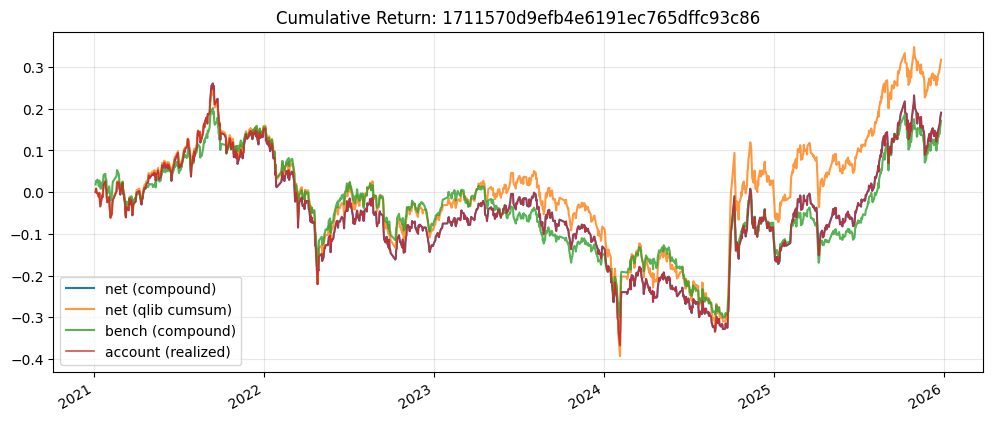

,gross,cost,net,nav_gross,nav_net,cumret_gross_compound,cumret_net_compound,cumret_gross_qlib_cumsum,cumret_net_qlib_cumsum,bench,nav_bench,cumret_bench_compound,cumret_bench_qlib_cumsum,nav_account,cumret_account
datetime,,,,,,,,,,,,,,,
2025-12-22,0.013201,0.000205,0.012996,1.459577,1.159287,0.459577,0.159287,0.520995,0.290648,0.012011,1.139553,0.139553,0.233096,1.159287,0.159287
2025-12-23,0.003654,0.000212,0.003442,1.464911,1.163277,0.464911,0.163277,0.524649,0.294090,0.000156,1.139731,0.139731,0.233252,1.163277,0.163277
2025-12-24,0.011592,0.000206,0.011386,1.481892,1.176522,0.481892,0.176522,0.536241,0.305476,0.013126,1.154691,0.154691,0.246377,1.176522,0.176522
2025-12-25,0.006453,0.000214,0.006239,1.491454,1.183862,0.491454,0.183862,0.542693,0.311715,0.007980,1.163905,0.163905,0.254357,1.183862,0.183862
2025-12-26,0.005755,0.000208,0.005547,1.500037,1.190429,0.500037,0.190429,0.548448,0.317261,0.006495,1.171464,0.171464,0.260852,1.190429,0.190429


In [43]:
if TARGET_PKL is None:
    raise SystemExit("No TARGET_PKL")

ret_df = _safe_read_pickle(TARGET_PKL)
curves = _compute_curves(ret_df)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(curves.index, curves["cumret_net_compound"], label="net (compound)")
ax.plot(curves.index, curves["cumret_net_qlib_cumsum"], label="net (qlib cumsum)", alpha=0.8)
if "cumret_bench_compound" in curves.columns:
    ax.plot(curves.index, curves["cumret_bench_compound"], label="bench (compound)", alpha=0.8)
if "cumret_account" in curves.columns:
    ax.plot(curves.index, curves["cumret_account"], label="account (realized)", linewidth=1.1, alpha=0.9)
ax.set_title(f"Cumulative Return: {TARGET_PKL.parent.name}")
ax.grid(True, alpha=0.3)
ax.legend()
fig.autofmt_xdate()
plt.show()

curves.tail()

## Multi-line plot (논문 그림처럼)

- 아래 `LABEL_TO_UUID` 또는 `LABEL_TO_PKL`에 원하는 run(uuid)만 넣으면 한 번에 overlay로 그려져요.
- 기본은 **Cumulative Excess Return (with cost)** 를 **qlib 방식(cumsum)** 으로 그립니다.


In [44]:
# ---- resolve label -> pkl_path (CN/US separately)
# 아래 두 dict만 바꾸면, CN/US 각각 그림 + perf_table이 따로 나옵니다.

LABEL_TO_UUID_CN: dict[str, str] = {
    # 예: "AlphaAgent": "<uuid>"
}
LABEL_TO_UUID_US: dict[str, str] = {
}

LABEL_TO_PKL_CN: dict[str, str] = {
    # (CN) 너가 준 run 디렉토리 경로
    "Alpha158":'/home/dgu/fin/01_15_new_qlib/paper/912768084596037704',
    "MACD": "/home/dgu/fin/01_15_new_qlib/paper/34f59ac282a7482996cc65579f4d9769",
    "LightGBM": "/home/dgu/fin/qlib/examples/mlruns/319457791950376549/627770fb8e524f8bb874bb8d364dfcba",
    "Linear" : "/home/dgu/mlruns/430189588706002109/25740f7b954d4ff99c99e59e5f2145d4",
    "MLP" : "/home/dgu/mlruns/430189588706002109/82a4574e6bb9409f91774a525b190fa3",
    "Transformer" : "/home/dgu/mlruns/430189588706002109/9abe2ab89b1d47d5ae00ab4fa4a2ab7e",
    "XGBoost" : "/home/dgu/mlruns/430189588706002109/48d720298d57429bbbcf05984eb70158",
    # "AlphaForge": "/home/dgu/fin/others/02_agent/AlphaForge/out_cn/backtest_csv/timeseries_test_2019_10_inf_0.csv",
    "R&D-Agent": "/home/dgu/fin/01_15_new_qlib copy/2026-02-03_06-31-06-947364.pkl",
    "AlphaAgent": "/home/dgu/fin/AlphaAgent/results/2026-02-03_17-23-06-199838/backtest/1711570d9efb4e6191ec765dffc93c86/ret.pkl",
    "Ours": "/home/dgu/fin/01_15_new_qlib/runs/20260207_051736/qlib_artifacts/iter_1/combo_51/oos/report_normal_1day.pkl",
}

LABEL_TO_PKL_US: dict[str, str] = {
    # (US) 너가 준 run 디렉토리 경로
    "Alpha158": "/home/dgu/fin/01_15_new_qlib/paper/dccaa4fae1874e6c987c2b97be5ff88a",
    "MACD": "/home/dgu/fin/01_15_new_qlib/paper/f5b39c82ab0b4e46a7ca5ede9b3861d0",
    "LightGBM": "/home/dgu/mlruns/430189588706002109/e32fe820378c4b17ba0f538f98c803bd",
    "Linear": "/home/dgu/mlruns/430189588706002109/22520a8aebdd447a83138a6237fafb4d",
    "MLP": "/home/dgu/mlruns/430189588706002109/8d729d2f97f44dd2a8f5b62bf8bba10f",
    "Transformer": "/home/dgu/mlruns/430189588706002109/dbba216ee2244931a232c8514fb2381e",
    "XGBoost": "/home/dgu/mlruns/430189588706002109/b29ad6acff344554a084278b115998b3",
    # "AlphaForge": "/home/dgu/fin/others/02_agent/AlphaForge/out/backtest_csv/timeseries_test_2019_10_inf_0.csv",
    "R&D-Agent": "/home/dgu/fin/01_15_new_qlib copy/2026-02-08_17-55-06-641095.pkl",
    "AlphaAgent": "/home/dgu/fin/01_15_new_qlib copy/2026-02-08_20-25-04-871469.pkl",
    "Ours": "/home/dgu/fin/01_15_new_qlib/runs/20260126_204618/qlib_artifacts/iter_1/combo_2/fixed_q90/oos/report_normal_1day.pkl",
    
}


In [45]:
ret_df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1209 entries, 2021-01-04 to 2025-12-26
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   account         1209 non-null   float64
 1   return          1209 non-null   float64
 2   total_turnover  1209 non-null   float64
 3   turnover        1209 non-null   float64
 4   total_cost      1209 non-null   float64
 5   cost            1209 non-null   float64
 6   value           1209 non-null   float64
 7   cash            1209 non-null   float64
 8   bench           1209 non-null   float64
dtypes: float64(9)
memory usage: 94.5 KB


In [46]:
# Multi-line cumulative excess return plot

PLOT_KIND = "excess_with_cost"  # "excess_with_cost" | "excess_without_cost"
CUM_METHOD = "qlib_cumsum"      # "qlib_cumsum" | "compound"
TOPK_FALLBACK = 6               # label 지정 안 하면 summary에서 top-K uuid를 자동 plot

# 1) uuid로 지정 (추천): summary에서 uuid -> pkl_path 매핑해서 씀
LABEL_TO_UUID: dict[str, str] = {
    # "AlphaAgent": "9b12639799ff4c8284d40fb003204cec",
}

# 2) pkl 경로로 직접 지정
# 2) (legacy) 단일 dict 방식 (CN/US 분리 코드에서는 아래 LABEL_TO_PKL_CN/US 사용)
LABEL_TO_PKL: dict[str, str] = {}


def _daily_excess_series_from_pkl(pkl_path: str, plot_kind: str) -> pd.Series:
    # AlphaForge CSV support: if path is CSV, read strategy/benchmark returns
    if str(pkl_path).lower().endswith(".csv"):
        df = pd.read_csv(pkl_path)
        # prefer active_ret if available
        if "active_ret" in df.columns:
            daily = pd.Series(df["active_ret"].astype(float))
        else:
            strat = df["strategy_ret"].astype(float) if "strategy_ret" in df.columns else None
            bench = df["benchmark_ret"].astype(float) if "benchmark_ret" in df.columns else None
            if strat is None:
                raise ValueError(f"CSV missing strategy_ret: {pkl_path}")
            if bench is None:
                bench = 0.0
            daily = pd.Series(strat - bench)
        daily = daily.fillna(0.0)
        # use date index for CSVs to align with PKL
        if "date" in df.columns:
            daily.index = pd.to_datetime(df["date"], errors="coerce")
            if daily.index.isna().any():
                raise ValueError(f"CSV has invalid dates: {pkl_path}")
        else:
            raise ValueError(f"CSV missing date column: {pkl_path}")
        daily.name = Path(pkl_path).stem
        return daily

    df = _safe_read_pickle(pkl_path)
    curves = _compute_curves(df)

    bench = curves["bench"] if "bench" in curves.columns else 0.0

    if plot_kind == "excess_with_cost":
        # net = return - cost
        daily = curves["net"] - bench
    elif plot_kind == "excess_without_cost":
        daily = curves["gross"] - bench
    else:
        raise ValueError(f"Unknown plot_kind: {plot_kind}")

    daily = daily.astype(float).fillna(0.0)
    daily.name = Path(pkl_path).parent.name
    return daily


def _cumulate(daily: pd.Series, method: str) -> pd.Series:
    if method == "qlib_cumsum":
        return daily.cumsum()
    if method == "compound":
        return (1.0 + daily).cumprod() - 1.0
    raise ValueError(f"Unknown method: {method}")


def _meta_from_stage4_report_pkl(report_pkl: Path) -> dict:
    # .../01_15_new_qlib/runs/<run_id>/qlib_artifacts/.../report_normal_1day.pkl
    try:
        parts = report_pkl.parts
        i = parts.index("runs")
        run_id = parts[i + 1]
    except Exception:
        return {}

    run_conf = report_pkl.parents[4] / "run_config.json"  # runs/<run_id>/run_config.json
    if not run_conf.exists():
        return {"run_id": run_id}

    try:
        import json

        obj = json.loads(run_conf.read_text(encoding="utf-8"))
        q = (obj.get("config") or {}).get("qlib") or {}
        return {
            "run_id": run_id,
            "region": q.get("region"),
            "market": q.get("qlib_market"),
            "benchmark": q.get("benchmark"),
            "provider_uri": q.get("provider_uri"),
            "conf_path": str(run_conf),
        }
    except Exception:
        return {"run_id": run_id}


def _mlflow_meta_from_report_pkl(report_pkl: Path) -> dict:
    # .../<run_id>/artifacts/.../report_normal_1day.pkl
    try:
        # find artifacts/ in parents
        artifacts_dir = None
        for parent in report_pkl.parents:
            if parent.name == "artifacts":
                artifacts_dir = parent
                break
        if artifacts_dir is None:
            return {}
        run_dir = artifacts_dir.parent
    except Exception:
        return {}

    d = {
        "source": "mlflow",
        "mlflow_run_id": run_dir.name,
        "mlflow_run_dir": str(run_dir),
    }

    # infer region/market from params if present
    try:
        inst_path = run_dir / "params" / "dataset.kwargs.handler.kwargs.instruments"
        if inst_path.exists():
            inst = inst_path.read_text(encoding="utf-8", errors="ignore").strip()
            if inst:
                d["market"] = inst
                inst_l = inst.lower()
                if inst_l in {"sp500", "sp_500", "s&p500", "snp500"}:
                    d["region"] = "us"
                elif inst_l.startswith("csi") or inst_l in {"csi500", "csi300"}:
                    d["region"] = "cn"
    except Exception:
        pass

    return d


def _meta_for_label_path(label: str, pkl_path: str) -> dict:
    p = Path(pkl_path)
    d = {"label": label, "pkl_path": pkl_path}

    # AlphaForge: infer region from path tokens (csi* -> cn, sp500 -> us)
    if "AlphaForge" in p.parts or "alphaforge" in str(p).lower():
        p_low = str(p).lower()
        if ("csi" in p_low) and ("region" not in d):
            d["region"] = "cn"
        elif ("sp500" in p_low or "snp" in p_low) and ("region" not in d):
            d["region"] = "us"

    # --- parse common fields from path for readability ---
    parts = list(p.parts)
    parts_lower = [x.lower() for x in parts]

    # run_id: AlphaAgent layout .../backtest/<run_id>/portfolio_analysis/report_normal_1day.pkl
    run_id = None
    if "backtest" in parts:
        try:
            i = parts.index("backtest")
            if i + 1 < len(parts):
                run_id = parts[i + 1]
        except Exception:
            pass
    d["run_id"] = run_id

    # run_date: parse from results folder name (YYYY-MM-DD_...) if present
    run_date = None
    for part in parts:
        if len(part) >= 10 and part[4] == '-' and part[7] == '-':
            run_date = part[:10]
            break
    d["run_date"] = run_date

    # backtest_type: folder just above report or portfolio_analysis
    backtest_type = None
    if "portfolio_analysis" in parts:
        try:
            j = parts.index("portfolio_analysis")
            if j - 1 >= 0:
                backtest_type = parts[j - 1]
        except Exception:
            pass
    d["backtest_type"] = backtest_type

    # region guess from path tokens if available
    region_guess = None
    if any(x == "cn" for x in parts_lower):
        region_guess = "cn"
    elif any(x == "us" for x in parts_lower):
        region_guess = "us"
    d["region_guess"] = region_guess

    if "01_15_new_qlib" in p.parts and "runs" in p.parts:
        d.update(_meta_from_stage4_report_pkl(p))
        d["source"] = "01_15_new_qlib"
        return d

    mlflow_meta = _mlflow_meta_from_report_pkl(p)
    if mlflow_meta:
        d.update(mlflow_meta)
        return d

    # AlphaAgent results ret.pkl: parent folder name is uuid
    ws_uuid = p.parent.name
    hit = None
    try:
        if "workspace_uuid" in summary.columns:
            h = summary[summary["workspace_uuid"] == ws_uuid]
            if len(h) > 0:
                hit = h.iloc[0]
    except Exception:
        hit = None

    if hit is not None:
        for k in ("region", "market", "benchmark", "provider_uri", "conf_path"):
            if k in hit.index and pd.notna(hit[k]):
                d[k] = hit[k]
    d["workspace_uuid"] = ws_uuid
    d["source"] = "AlphaAgent" if "AlphaAgent" in p.parts else "(other)"
    return d




def _resolve_report_pkl_path(p: str) -> str:
    pp = Path(p)
    if pp.is_dir():
        # AlphaForge: prefer timeseries_test*.csv under the directory
        af_csv = sorted(pp.glob("**/timeseries_test_*.csv"), key=lambda x: x.stat().st_mtime, reverse=True)
        if af_csv:
            return str(af_csv[0])

        # Common MLflow layout: <run_dir>/artifacts/portfolio_analysis/report_normal_1day.pkl
        cand = pp / "artifacts" / "portfolio_analysis" / "report_normal_1day.pkl"
        if cand.exists():
            return str(cand)

        # Some exports nest runs under an extra directory; search a bit deeper.
        matches = list(pp.glob("**/artifacts/portfolio_analysis/report_normal_1day.pkl"))
        if matches:
            # Pick the newest report if multiple exist.
            matches.sort(key=lambda x: x.stat().st_mtime, reverse=True)
            return str(matches[0])

    return str(pp)


def _apply_uuid_map(label_to_pkl: dict[str, str], label_to_uuid: dict[str, str]) -> dict[str, str]:
    out = dict(label_to_pkl)
    for label, uid in (label_to_uuid or {}).items():
        hit = summary[summary["workspace_uuid"] == uid]
        if len(hit) == 0:
            raise ValueError(f"uuid not found in summary: {uid}")
        out[label] = str(hit.iloc[0]["pkl_path"])
    return out


def _resolve_map(m: dict[str, str]) -> dict[str, str]:
    return {k: _resolve_report_pkl_path(v) for k, v in (m or {}).items()}


label_to_pkl_cn = _apply_uuid_map(_resolve_map(LABEL_TO_PKL_CN), LABEL_TO_UUID_CN)
label_to_pkl_us = _apply_uuid_map(_resolve_map(LABEL_TO_PKL_US), LABEL_TO_UUID_US)


# ---- plot + tables for a given set
from IPython.display import display

TRADING_DAYS = 252

def _mlflow_metrics_dir_from_pkl(pkl_path: str):
    p = Path(pkl_path)
    for parent in p.parents:
        if parent.name == "artifacts":
            metrics_dir = parent.parent / "metrics"
            return metrics_dir if metrics_dir.exists() else None
    return None

def _read_mlflow_metric(metrics_dir: Path, key: str) -> float:
    fp = metrics_dir / key
    if not fp.exists():
        return float("nan")
    try:
        lines = fp.read_text(encoding="utf-8", errors="ignore").splitlines()
        for line in reversed(lines):
            line = line.strip()
            if not line:
                continue
            parts = line.split()
            # MLflow metrics file format: "<timestamp_ms> <value> <step>"
            if len(parts) >= 2:
                return float(parts[1])
    except Exception:
        return float("nan")
    return float("nan")

def _try_mlflow_excess_metrics(pkl_path: str, plot_kind: str) -> dict:
    metrics_dir = _mlflow_metrics_dir_from_pkl(pkl_path)
    if metrics_dir is None:
        return {}
    prefix = "1day.excess_return_with_cost" if plot_kind == "excess_with_cost" else "1day.excess_return_without_cost"
    out = {
        "AR": _read_mlflow_metric(metrics_dir, f"{prefix}.annualized_return"),
        "IR": _read_mlflow_metric(metrics_dir, f"{prefix}.information_ratio"),
        "MDD": _read_mlflow_metric(metrics_dir, f"{prefix}.max_drawdown"),
        "mean": _read_mlflow_metric(metrics_dir, f"{prefix}.mean"),
        "std": _read_mlflow_metric(metrics_dir, f"{prefix}.std"),
        "mlflow_metrics_dir": str(metrics_dir),
    }
    if all((not np.isfinite(v)) for k, v in out.items() if k in {"AR", "IR", "MDD", "mean", "std"}):
        return {}
    return out



def _port_analysis_path_from_pkl(pkl_path: str):
    p = Path(pkl_path)

    # AlphaAgent ret.pkl layout: .../backtest/<uuid>/ret.pkl
    if p.name == "ret.pkl":
        cand = p.parent / "portfolio_analysis" / "port_analysis_1day.pkl"
        if cand.exists():
            return cand

    # Qlib report layout: sibling port_analysis_1day.pkl next to report_normal_1day.pkl
    if p.name == "report_normal_1day.pkl":
        cand = p.parent / "port_analysis_1day.pkl"
        if cand.exists():
            return cand

    return None


def _try_qlib_port_analysis_metrics(pkl_path: str, plot_kind: str) -> dict:
    pa_path = _port_analysis_path_from_pkl(pkl_path)
    if pa_path is None:
        return {}

    try:
        pa = _safe_read_pickle(pa_path)
    except Exception:
        return {}

    if not isinstance(pa, pd.DataFrame) or pa.shape[1] == 0:
        return {}

    key0 = "excess_return_with_cost" if plot_kind == "excess_with_cost" else "excess_return_without_cost"

    try:
        if isinstance(pa.index, pd.MultiIndex):
            sub = pa.loc[key0]
        else:
            return {}
    except Exception:
        return {}

    # sub is a DataFrame indexed by metric name (mean/std/annualized_return/...)
    def _get(name: str):
        try:
            v = sub.loc[name].iloc[0]
            return float(v)
        except Exception:
            return float('nan')

    out = {
        'AR': _get('annualized_return'),
        'IR': _get('information_ratio'),
        'MDD': _get('max_drawdown'),
        'mean': _get('mean'),
        'std': _get('std'),
        'qlib_port_analysis_path': str(pa_path),
    }

    if all((not np.isfinite(out[k])) for k in ('AR','IR','MDD','mean','std')):
        return {}

    return out

label_to_pkl_cn, label_to_pkl_us

({'Alpha158': '/home/dgu/fin/01_15_new_qlib/paper/912768084596037704/912768084596037704/05d1deca2bbd44bd8c393561b8e2c965/artifacts/portfolio_analysis/report_normal_1day.pkl',
  'MACD': '/home/dgu/fin/01_15_new_qlib/paper/34f59ac282a7482996cc65579f4d9769/artifacts/portfolio_analysis/report_normal_1day.pkl',
  'LightGBM': '/home/dgu/fin/qlib/examples/mlruns/319457791950376549/627770fb8e524f8bb874bb8d364dfcba/artifacts/portfolio_analysis/report_normal_1day.pkl',
  'Linear': '/home/dgu/mlruns/430189588706002109/25740f7b954d4ff99c99e59e5f2145d4/artifacts/portfolio_analysis/report_normal_1day.pkl',
  'MLP': '/home/dgu/mlruns/430189588706002109/82a4574e6bb9409f91774a525b190fa3/artifacts/portfolio_analysis/report_normal_1day.pkl',
  'Transformer': '/home/dgu/mlruns/430189588706002109/9abe2ab89b1d47d5ae00ab4fa4a2ab7e/artifacts/portfolio_analysis/report_normal_1day.pkl',
  'XGBoost': '/home/dgu/mlruns/430189588706002109/48d720298d57429bbbcf05984eb70158/artifacts/portfolio_analysis/report_normal_

## (옵션) 01_15_new_qlib Stage4 artifacts에서 report_normal_1day.pkl 스캔

원하면 아래 셀을 켜서 `runs/<run_id>/qlib_artifacts/**/report_normal_1day.pkl`도 동일하게 요약할 수 있어요.

In [47]:
# ENABLE_STAGE4_SCAN = True
ENABLE_STAGE4_SCAN = False

def find_stage4_report_pkls(project_root: Path, *, max_files: int = 200) -> list[Path]:
    runs_dir = project_root / "runs"
    if not runs_dir.exists():
        return []
    pkls = list(runs_dir.glob("*/qlib_artifacts/**/report_normal_1day.pkl"))
    pkls.sort(key=lambda p: p.stat().st_mtime if p.exists() else 0, reverse=True)
    return pkls[:max_files]

if ENABLE_STAGE4_SCAN:
    stage4_pkls = find_stage4_report_pkls(PROJECT_ROOT, max_files=MAX_FILES)
    stage4_rows = []
    for p in stage4_pkls:
        d = {
            "pkl_path": str(p),
            "run_id": (p.parts[p.parts.index("runs") + 1] if "runs" in p.parts else None),
        }
        try:
            df = _safe_read_pickle(p)
            curves = _compute_curves(df)
            d["start"] = curves.index.min()
            d["end"] = curves.index.max()
            d["cumret_net_compound"] = float(curves["cumret_net_compound"].iloc[-1])
            d["cumret_net_qlib_cumsum"] = float(curves["cumret_net_qlib_cumsum"].iloc[-1])
        except Exception as e:
            d["error"] = f"{type(e).__name__}: {e}"
        stage4_rows.append(d)
    stage4_summary = pd.DataFrame(stage4_rows).sort_values(["run_id"], ascending=False)
    stage4_summary.head(30)
else:
    "(Stage4 scan disabled)"

In [48]:
from qlib.contrib.evaluate import risk_analysis

def _plot_set(label_to_pkl_dict, title_suffix=""):
    series = {}
    rows = []
    for label, pkl_path in label_to_pkl_dict.items():
        if not Path(pkl_path).exists():
            print(f"Warning: {pkl_path} not found for {label}")
            continue

        daily = _daily_excess_series_from_pkl(pkl_path, PLOT_KIND)
        series[label] = _cumulate(daily, CUM_METHOD)

        # 기본 성과: risk_analysis로 계산
        ra = risk_analysis(daily, freq='day')
        row = {
            'label': label,
            'AR': float(ra.loc['annualized_return', 'risk']),
            'IR': float(ra.loc['information_ratio', 'risk']),
            'MDD': float(ra.loc['max_drawdown', 'risk']),
            'mean': float(ra.loc['mean', 'risk']),
            'std': float(ra.loc['std', 'risk']),
            'CR': float(series[label].iloc[-1]),
        }
        rows.append(row)

    if not series:
        return None

    curve_df = pd.concat(series, axis=1).sort_index().ffill()

    plt.figure(figsize=(12, 5))
    for col in curve_df.columns:
        plt.plot(curve_df.index, curve_df[col], label=col)
    plt.axhline(0.0, linestyle="--", color="black", linewidth=1.5, alpha=0.8, label="Benchmark")
    plt.xlim(pd.Timestamp("2021-01-01"), pd.Timestamp("2025-12-31"))
    plt.title(f"Cumulative Excess Return - {title_suffix}")
    plt.legend()
    plt.show()

    perf_table = pd.DataFrame(rows)
    return {"perf_table": perf_table, "curve_df": curve_df}


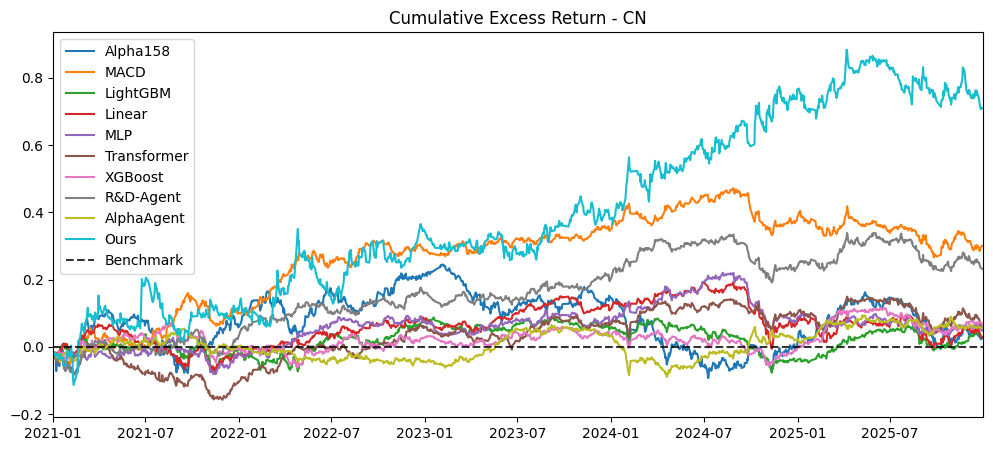

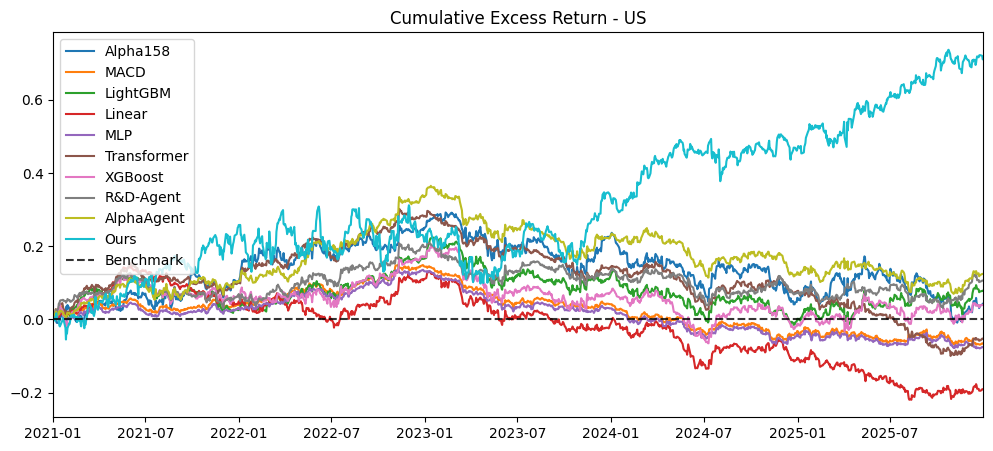

In [49]:
out_cn = _plot_set(label_to_pkl_cn, "CN")
perf_table_cn = out_cn["perf_table"] if out_cn else pd.DataFrame()

out_us = _plot_set(label_to_pkl_us, "US")
perf_table_us = out_us["perf_table"] if out_us else pd.DataFrame()


In [50]:
from IPython.display import display

print('CN perf_table')
display(perf_table_cn[['label','AR','IR','MDD','CR','mean','std']])

print('US perf_table')
display(perf_table_us[['label','AR','IR','MDD','CR','mean','std']])


CN perf_table


,label,AR,IR,MDD,CR,mean,std
0,Alpha158,0.005073,0.037752,-0.337754,0.025790,0.000021,0.008710
1,MACD,0.059146,0.619587,-0.205418,0.300699,0.000249,0.006188
2,LightGBM,0.005789,0.070252,-0.164170,0.029434,0.000024,0.005342
3,Linear,0.005372,0.063072,-0.197551,0.027310,0.000023,0.005521
4,MLP,0.009358,0.117366,-0.186664,0.047574,0.000039,0.005168
5,Transformer,0.011236,0.136197,-0.168701,0.057123,0.000047,0.005347
6,XGBoost,0.013047,0.178097,-0.133201,0.066331,0.000055,0.004749
7,R&D-Agent,0.045583,0.544300,-0.142634,0.231744,0.000192,0.005428
8,AlphaAgent,0.011105,0.162013,-0.154774,0.056409,0.000047,0.004443
9,Ours,0.139739,0.647039,-0.222351,0.710439,0.000587,0.013999


US perf_table


,label,AR,IR,MDD,CR,mean,std
0,Alpha158,0.008110,0.060738,-0.301314,0.042766,0.000034,0.008655
1,MACD,-0.012608,-0.228402,-0.218173,-0.066481,-0.000053,0.003578
2,LightGBM,0.014682,0.143835,-0.238831,0.077418,0.000062,0.006616
3,Linear,-0.036292,-0.422064,-0.365288,-0.191371,-0.000152,0.005574
4,MLP,-0.014518,-0.263673,-0.214882,-0.076556,-0.000061,0.003569
5,Transformer,-0.010096,-0.121344,-0.402192,-0.053237,-0.000042,0.005393
6,XGBoost,0.007441,0.072577,-0.264782,0.039236,0.000031,0.006646
7,R&D-Agent,0.020150,0.232742,-0.177681,0.106082,0.000085,0.005612
8,AlphaAgent,0.023604,0.255301,-0.295295,0.124268,0.000099,0.005993
9,Ours,0.134753,0.706875,-0.214170,0.710568,0.000566,0.012357


out/backtest_csv/timeseries_test_2019_10_inf_0.csv
out/backtest_csv/timeseries_valid_2019_10_inf_0.csv
out/test_csi500_2019_0/timeseries_test_2019_10_inf_0.csv
out/test_csi500_2019_0/timeseries_valid_2019_10_inf_0.csv
out_cn/backtest_csv/timeseries_test_2019_10_inf_0.csv
out_cn/backtest_csv/timeseries_valid_2019_10_inf_0.csv


In [51]:
# AlphaForge backtest CSV -> excess_return_with_cost metrics
from pathlib import Path
import pandas as pd
import numpy as np

# Pick one CSV (edit as needed)
root = Path('/home/dgu/fin/others/02_agent/AlphaForge')
# Prefer test CSV; fall back to any timeseries CSV
candidates = list(root.glob('out/backtest_csv/timeseries_test_*.csv'))
if not candidates:
    candidates = list(root.glob('out/backtest_csv/timeseries_*.csv'))
if not candidates:
    candidates = list(root.glob('out_cn/backtest_csv/timeseries_test_*.csv'))
if not candidates:
    candidates = list(root.glob('out_cn/backtest_csv/timeseries_*.csv'))

if not candidates:
    raise FileNotFoundError('No timeseries CSV found under AlphaForge/out*/backtest_csv')

csv_path = candidates[0]
print('Using CSV:', csv_path)

df = pd.read_csv(csv_path)

required = {'strategy_ret', 'benchmark_ret', 'active_ret', 'relative_cumret'}
missing = required - set(df.columns)
if missing:
    raise ValueError(f'Missing columns in CSV: {missing}')

# excess_return_with_cost assumed = active_ret (strategy_ret already cost-adjusted in backtest_pred.py)
excess = df['active_ret'].astype(float).replace([np.inf, -np.inf], np.nan).dropna()
rel_cum = df['relative_cumret'].astype(float).replace([np.inf, -np.inf], np.nan)
rel_cum = rel_cum.dropna()

n_days = len(excess)
if n_days < 2:
    raise ValueError('Not enough data to compute metrics')

# CR: total relative cumulative return (end of period)
cr = float(rel_cum.iloc[-1])

# AR: annualized return from CR
ar = float((1.0 + cr) ** (252.0 / n_days) - 1.0) if cr > -1.0 else float('nan')

# IR: annualized mean / std of active returns
mean = float(excess.mean())
std = float(excess.std(ddof=1)) if n_days > 1 else 0.0
ir = float(np.sqrt(252.0) * mean / std) if std > 0 else float('nan')

# MDD: max drawdown on relative equity curve
rel_equity = (1.0 + excess.fillna(0.0)).cumprod().values
peak = np.maximum.accumulate(rel_equity)
with np.errstate(divide='ignore', invalid='ignore'):
    dd = 1.0 - (rel_equity / peak)
    mdd = float(np.nanmax(dd)) if len(dd) else float('nan')

print('excess_return_with_cost metrics')
print({
    'n_days': n_days,
    'CR': cr,
    'AR': ar,
    'IR': ir,
    'MDD': mdd,
    'mean': mean,
    'std': std,
})


Using CSV: /home/dgu/fin/others/02_agent/AlphaForge/out/backtest_csv/timeseries_test_2019_10_inf_0.csv
excess_return_with_cost metrics
{'n_days': 1235, 'CR': 0.9650345856062192, 'AR': 0.14778824679555047, 'IR': 0.8661985541184414, 'MDD': 0.23286182215048667, 'mean': 0.0006093345947387697, 'std': 0.011167054910738196}


In [52]:
# AlphaForge backtest CSV -> batch excess_return_with_cost metrics
from pathlib import Path
import pandas as pd
import numpy as np

root = Path('/home/dgu/fin/others/02_agent/AlphaForge')
files = sorted(root.glob('out/backtest_csv/timeseries_*.csv'))
files += sorted(root.glob('out/test_csi500_2019_0/timeseries_*.csv'))
files += sorted(root.glob('out_cn/backtest_csv/timeseries_*.csv'))

if not files:
    raise FileNotFoundError('No timeseries CSV found under AlphaForge/out*/backtest_csv')

rows = []
for csv_path in files:
    df = pd.read_csv(csv_path)
    required = {'strategy_ret', 'benchmark_ret', 'active_ret', 'relative_cumret'}
    missing = required - set(df.columns)
    if missing:
        rows.append({'path': str(csv_path), 'error': f'missing columns: {missing}'})
        continue

    excess = df['active_ret'].astype(float).replace([np.inf, -np.inf], np.nan).dropna()
    rel_cum = df['relative_cumret'].astype(float).replace([np.inf, -np.inf], np.nan).dropna()
    n_days = len(excess)
    if n_days < 2:
        rows.append({'path': str(csv_path), 'error': 'not enough data'})
        continue

    cr = float(rel_cum.iloc[-1])
    ar = float((1.0 + cr) ** (252.0 / n_days) - 1.0) if cr > -1.0 else float('nan')
    mean = float(excess.mean())
    std = float(excess.std(ddof=1)) if n_days > 1 else 0.0
    ir = float(np.sqrt(252.0) * mean / std) if std > 0 else float('nan')

    rel_equity = (1.0 + excess.fillna(0.0)).cumprod().values
    peak = np.maximum.accumulate(rel_equity)
    with np.errstate(divide='ignore', invalid='ignore'):
        dd = 1.0 - (rel_equity / peak)
        mdd = float(np.nanmax(dd)) if len(dd) else float('nan')

    rows.append({
        'path': str(csv_path),
        'n_days': n_days,
        'CR': cr,
        'AR': ar,
        'IR': ir,
        'MDD': mdd,
        'mean': mean,
        'std': std,
    })

result = pd.DataFrame(rows)
result = result.sort_values(['path'])
result


,path,n_days,CR,AR,IR,MDD,mean,std
0,/home/dgu/fin/others/02_agent/AlphaForge/out/b...,1235,0.965035,0.147788,0.866199,0.232862,0.000609,0.011167
1,/home/dgu/fin/others/02_agent/AlphaForge/out/b...,252,0.227614,0.227614,0.683302,0.391232,0.001210,0.028104
2,/home/dgu/fin/others/02_agent/AlphaForge/out/t...,1179,-0.054544,-0.011917,0.023084,0.445363,0.000017,0.011388
3,/home/dgu/fin/others/02_agent/AlphaForge/out/t...,242,0.151419,0.158147,0.819005,0.136896,0.000668,0.012956
4,/home/dgu/fin/others/02_agent/AlphaForge/out_c...,1179,-0.054544,-0.011917,0.023084,0.445363,0.000017,0.011388
5,/home/dgu/fin/others/02_agent/AlphaForge/out_c...,242,0.151419,0.158147,0.819005,0.136896,0.000668,0.012956


In [53]:
# AlphaForge backtest CSV -> Qlib risk_analysis (excess_return_with_cost)
from pathlib import Path
import pandas as pd
import numpy as np
from qlib.contrib.evaluate import risk_analysis

root = Path('/home/dgu/fin/others/02_agent/AlphaForge')
files = sorted(root.glob('out/backtest_csv/timeseries_*.csv'))
files += sorted(root.glob('out/test_csi500_2019_0/timeseries_*.csv'))
files += sorted(root.glob('out_cn/backtest_csv/timeseries_*.csv'))

if not files:
    raise FileNotFoundError('No timeseries CSV found under AlphaForge/out*/backtest_csv')

rows = []
for csv_path in files:
    df = pd.read_csv(csv_path)
    required = {'active_ret', 'relative_cumret'}
    missing = required - set(df.columns)
    if missing:
        rows.append({'path': str(csv_path), 'error': f'missing columns: {missing}'})
        continue

    excess = df['active_ret'].astype(float).replace([np.inf, -np.inf], np.nan).dropna()
    n_days = len(excess)
    if n_days < 2:
        rows.append({'path': str(csv_path), 'error': 'not enough data'})
        continue

    ra = risk_analysis(excess, freq='day')
    # Qlib risk_analysis outputs a DataFrame indexed by metric name, column 'risk'
    try:
        ar = float(ra.loc['annualized_return', 'risk'])
        ir = float(ra.loc['information_ratio', 'risk'])
        mdd = float(ra.loc['max_drawdown', 'risk'])
        mean = float(ra.loc['mean', 'risk'])
        std = float(ra.loc['std', 'risk'])
    except Exception as e:
        rows.append({'path': str(csv_path), 'error': f'risk_analysis parse failed: {e}'})
        continue

    # CR from relative cumulative return end (same as excess cumulative return)
    rel_cum = df['relative_cumret'].astype(float).replace([np.inf, -np.inf], np.nan).dropna()
    cr = float(rel_cum.iloc[-1]) if len(rel_cum) else float('nan')

    rows.append({
        'path': str(csv_path),
        'n_days': n_days,
        'CR': cr,
        'AR': ar,
        'IR': ir,
        'MDD': mdd,
        'mean': mean,
        'std': std,
    })

result = pd.DataFrame(rows).sort_values(['path'])
result


,path,n_days,CR,AR,IR,MDD,mean,std
0,/home/dgu/fin/others/02_agent/AlphaForge/out/b...,1235,0.965035,0.145022,0.841794,-0.258270,0.000609,0.011167
1,/home/dgu/fin/others/02_agent/AlphaForge/out/b...,252,0.227614,0.287910,0.664051,-0.463497,0.001210,0.028104
2,/home/dgu/fin/others/02_agent/AlphaForge/out/t...,1179,-0.054544,0.003941,0.022434,-0.559682,0.000017,0.011388
3,/home/dgu/fin/others/02_agent/AlphaForge/out/t...,242,0.151419,0.159087,0.795929,-0.140666,0.000668,0.012956
4,/home/dgu/fin/others/02_agent/AlphaForge/out_c...,1179,-0.054544,0.003941,0.022434,-0.559682,0.000017,0.011388
5,/home/dgu/fin/others/02_agent/AlphaForge/out_c...,242,0.151419,0.159087,0.795929,-0.140666,0.000668,0.012956


In [54]:
# AlphaForge backtest CSV -> Qlib risk_analysis with region tag
from pathlib import Path
import pandas as pd
import numpy as np
from qlib.contrib.evaluate import risk_analysis

root = Path('/home/dgu/fin/others/02_agent/AlphaForge')
files = sorted(root.glob('out/backtest_csv/timeseries_*.csv'))
files += sorted(root.glob('out/test_csi500_2019_0/timeseries_*.csv'))
files += sorted(root.glob('out_cn/backtest_csv/timeseries_*.csv'))

if not files:
    raise FileNotFoundError('No timeseries CSV found under AlphaForge/out*/backtest_csv')

def _region_from_path(p: Path) -> str:
    s = str(p).lower()
    if 'out_cn' in s or 'csi500' in s:
        return 'cn'
    if 'sp500' in s:
        return 'us'
    # fallback: unknown
    return 'unknown'

rows = []
for csv_path in files:
    df = pd.read_csv(csv_path)
    required = {'active_ret', 'relative_cumret'}
    missing = required - set(df.columns)
    if missing:
        rows.append({'path': str(csv_path), 'region': _region_from_path(csv_path), 'error': f'missing columns: {missing}'})
        continue

    excess = df['active_ret'].astype(float).replace([np.inf, -np.inf], np.nan).dropna()
    n_days = len(excess)
    if n_days < 2:
        rows.append({'path': str(csv_path), 'region': _region_from_path(csv_path), 'error': 'not enough data'})
        continue

    ra = risk_analysis(excess, freq='day')
    try:
        ar = float(ra.loc['annualized_return', 'risk'])
        ir = float(ra.loc['information_ratio', 'risk'])
        mdd = float(ra.loc['max_drawdown', 'risk'])
        mean = float(ra.loc['mean', 'risk'])
        std = float(ra.loc['std', 'risk'])
    except Exception as e:
        rows.append({'path': str(csv_path), 'region': _region_from_path(csv_path), 'error': f'risk_analysis parse failed: {e}'})
        continue

    rel_cum = df['relative_cumret'].astype(float).replace([np.inf, -np.inf], np.nan).dropna()
    cr = float(rel_cum.iloc[-1]) if len(rel_cum) else float('nan')

    rows.append({
        'path': str(csv_path),
        'region': _region_from_path(csv_path),
        'n_days': n_days,
        'CR': cr,
        'AR': ar,
        'IR': ir,
        'MDD': mdd,
        'mean': mean,
        'std': std,
    })

result = pd.DataFrame(rows).sort_values(['region', 'path'])
result


,path,region,n_days,CR,AR,IR,MDD,mean,std
2,/home/dgu/fin/others/02_agent/AlphaForge/out/t...,cn,1179,-0.054544,0.003941,0.022434,-0.559682,0.000017,0.011388
3,/home/dgu/fin/others/02_agent/AlphaForge/out/t...,cn,242,0.151419,0.159087,0.795929,-0.140666,0.000668,0.012956
4,/home/dgu/fin/others/02_agent/AlphaForge/out_c...,cn,1179,-0.054544,0.003941,0.022434,-0.559682,0.000017,0.011388
5,/home/dgu/fin/others/02_agent/AlphaForge/out_c...,cn,242,0.151419,0.159087,0.795929,-0.140666,0.000668,0.012956
0,/home/dgu/fin/others/02_agent/AlphaForge/out/b...,unknown,1235,0.965035,0.145022,0.841794,-0.258270,0.000609,0.011167
1,/home/dgu/fin/others/02_agent/AlphaForge/out/b...,unknown,252,0.227614,0.287910,0.664051,-0.463497,0.001210,0.028104


In [55]:
alag1 = pd.read_csv('/home/dgu/fin/01_15_new_qlib/analysis/alphaagent_perf.csv')
alag1

,path,n_days,CR,AR,IR,MDD,mean,std,region,region_source,instruments,market,conf_path
0,/home/dgu/fin/AlphaAgent/results/2026-02-03_05...,1252,10.656981,0.639382,1.096886,-0.259564,0.002475,0.035822,NaN,NaN,NaN,NaN,NaN
1,/home/dgu/fin/AlphaAgent/results/2026-02-03_17...,1209,0.045497,0.009317,0.166779,-0.145056,0.000047,0.004441,NaN,NaN,NaN,NaN,NaN
2,/home/dgu/fin/AlphaAgent/results/2026-02-03_10...,1209,0.045497,0.009317,0.166779,-0.145056,0.000047,0.004441,NaN,NaN,NaN,NaN,NaN
3,/home/dgu/fin/AlphaAgent/results/2026-02-03_05...,1209,0.045497,0.009317,0.166779,-0.145056,0.000047,0.004441,NaN,NaN,NaN,NaN,NaN
4,/home/dgu/fin/AlphaAgent/results/2026-02-03_14...,1209,0.045497,0.009317,0.166779,-0.145056,0.000047,0.004441,NaN,NaN,NaN,NaN,NaN
5,/home/dgu/fin/AlphaAgent/results/2026-02-03_14...,1209,0.045497,0.009317,0.166779,-0.145056,0.000047,0.004441,NaN,NaN,NaN,NaN,NaN
6,/home/dgu/fin/AlphaAgent/results/2026-02-03_07...,1209,0.045497,0.009317,0.166779,-0.145056,0.000047,0.004441,NaN,NaN,NaN,NaN,NaN
7,/home/dgu/fin/AlphaAgent/results/2026-02-03_08...,1209,0.045497,0.009317,0.166779,-0.145056,0.000047,0.004441,NaN,NaN,NaN,NaN,NaN
8,/home/dgu/fin/AlphaAgent/results/2026-02-03_06...,1209,0.045497,0.009317,0.166779,-0.145056,0.000047,0.004441,NaN,NaN,NaN,NaN,NaN
9,/home/dgu/fin/AlphaAgent/results/2026-02-03_16...,1209,0.045497,0.009317,0.166779,-0.145056,0.000047,0.004441,NaN,NaN,NaN,NaN,NaN


In [56]:
alag2 = pd.read_csv('/home/dgu/fin/01_15_new_qlib/analysis/alphaagent_perf_others.csv')
alag2

,path,n_days,CR,AR,IR,MDD,mean,std,region,region_source,instruments,market,conf_path
0,/home/dgu/fin/others/02_agent/AlphaAgent/git_i...,1210,0.134300,0.026592,0.551921,-0.099954,0.000109,0.003137,cn,mlflow_params,csi500,NaN,NaN
1,/home/dgu/fin/others/02_agent/AlphaAgent/git_i...,968,0.002096,0.000545,0.047206,-0.182402,0.000015,0.005101,cn,mlflow_params,csi500,NaN,NaN
2,/home/dgu/fin/others/02_agent/AlphaAgent/git_i...,968,-0.025927,-0.006815,-0.019914,-0.212817,-0.000008,0.006223,cn,mlflow_params,csi500,NaN,NaN
3,/home/dgu/fin/others/02_agent/AlphaAgent/git_i...,968,-0.023316,-0.006123,-0.036899,-0.176157,-0.000012,0.005037,cn,mlflow_params,csi500,NaN,NaN
4,/home/dgu/fin/others/02_agent/AlphaAgent/git_i...,968,-0.096440,-0.026055,-0.308812,-0.175036,-0.000093,0.004795,cn,mlflow_params,csi500,NaN,NaN
5,/home/dgu/fin/others/02_agent/AlphaAgent/git_i...,968,-0.161521,-0.044826,-0.375136,-0.246343,-0.000159,0.006740,cn,mlflow_params,csi500,NaN,NaN


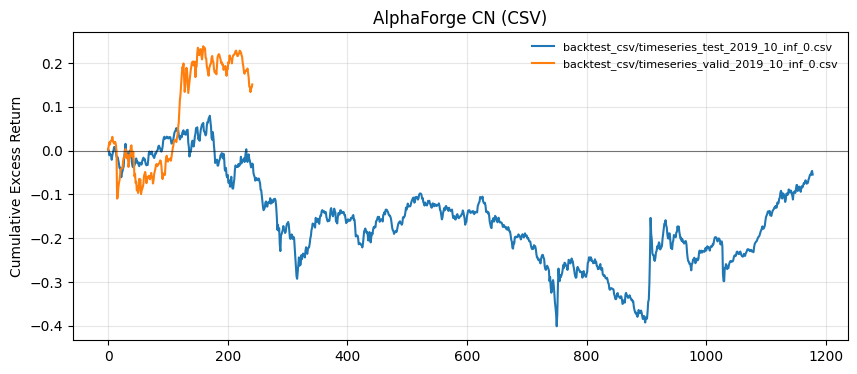

No sp500 CSVs found under out/


In [57]:

# ---- AlphaForge CSV plots (separate) ----
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

AF_CN_DIR = Path('/home/dgu/fin/others/02_agent/AlphaForge/out_cn')
AF_OUT_DIR = Path('/home/dgu/fin/others/02_agent/AlphaForge/out')


def _af_load_active(csv_path: Path) -> pd.Series:
    df = pd.read_csv(csv_path)
    if 'active_ret' in df.columns:
        daily = pd.Series(df['active_ret'].astype(float))
    else:
        strat = df['strategy_ret'].astype(float) if 'strategy_ret' in df.columns else None
        bench = df['benchmark_ret'].astype(float) if 'benchmark_ret' in df.columns else None
        if strat is None:
            raise ValueError(f"CSV missing strategy_ret: {csv_path}")
        if bench is None:
            bench = 0.0
        daily = strat - bench
    daily = daily.replace([float('inf'), float('-inf')], pd.NA).fillna(0.0)
    return daily


def _af_plot_dir(csv_dir: Path, title: str):
    csvs = sorted(csv_dir.rglob('timeseries_*_*.csv'))
    if not csvs:
        print(f"No CSVs found under {csv_dir}")
        return
    fig, ax = plt.subplots(figsize=(10, 4))
    for p in csvs:
        try:
            daily = _af_load_active(p)
            cum = (1.0 + daily).cumprod() - 1.0
            ax.plot(cum.values, label=p.relative_to(csv_dir).as_posix())
        except Exception as e:
            print(f"skip {p}: {e}")
    ax.axhline(0.0, color='black', linewidth=0.8, alpha=0.5)
    ax.set_title(title)
    ax.set_ylabel('Cumulative Excess Return')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8, frameon=False)
    plt.show()


# CN only (out_cn)
_af_plot_dir(AF_CN_DIR, 'AlphaForge CN (CSV)')

# US-only attempt from out/ (only sp500 CSVs if exist)
sp500_csvs = sorted([p for p in AF_OUT_DIR.rglob('timeseries_*_*.csv') if 'sp500' in str(p).lower()])
if sp500_csvs:
    fig, ax = plt.subplots(figsize=(10, 4))
    for p in sp500_csvs:
        try:
            daily = _af_load_active(p)
            cum = (1.0 + daily).cumprod() - 1.0
            ax.plot(cum.values, label=p.relative_to(AF_OUT_DIR).as_posix())
        except Exception as e:
            print(f"skip {p}: {e}")
    ax.axhline(0.0, color='black', linewidth=0.8, alpha=0.5)
    ax.set_title('AlphaForge US (CSV, sp500 only)')
    ax.set_ylabel('Cumulative Excess Return')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8, frameon=False)
    plt.show()
else:
    print('No sp500 CSVs found under out/')


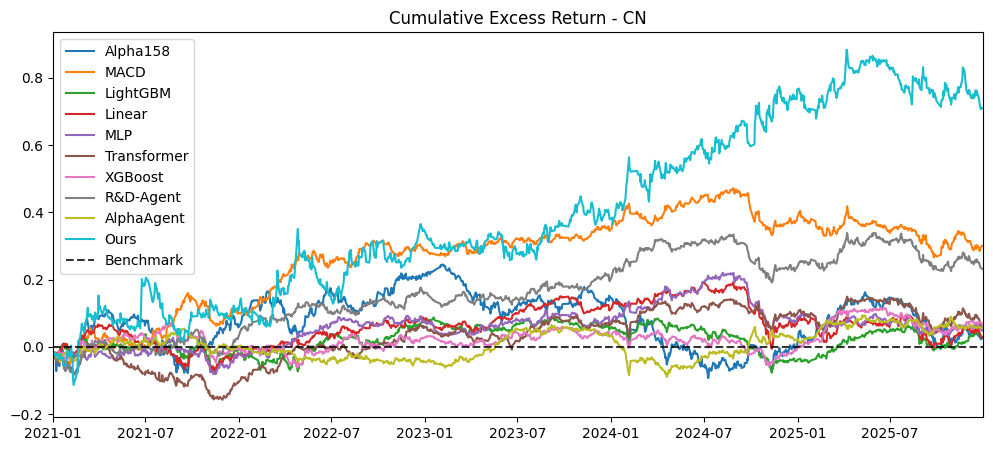

         label        AR        IR       MDD      mean       std        CR
0     Alpha158  0.005073  0.037752 -0.337754  0.000021  0.008710  0.025790
1         MACD  0.059146  0.619587 -0.205418  0.000249  0.006188  0.300699
2     LightGBM  0.005789  0.070252 -0.164170  0.000024  0.005342  0.029434
3       Linear  0.005372  0.063072 -0.197551  0.000023  0.005521  0.027310
4          MLP  0.009358  0.117366 -0.186664  0.000039  0.005168  0.047574
5  Transformer  0.011236  0.136197 -0.168701  0.000047  0.005347  0.057123
6      XGBoost  0.013047  0.178097 -0.133201  0.000055  0.004749  0.066331
7    R&D-Agent  0.045583  0.544300 -0.142634  0.000192  0.005428  0.231744
8   AlphaAgent  0.011105  0.162013 -0.154774  0.000047  0.004443  0.056409
9         Ours  0.139739  0.647039 -0.222351  0.000587  0.013999  0.710439
CN perf_table


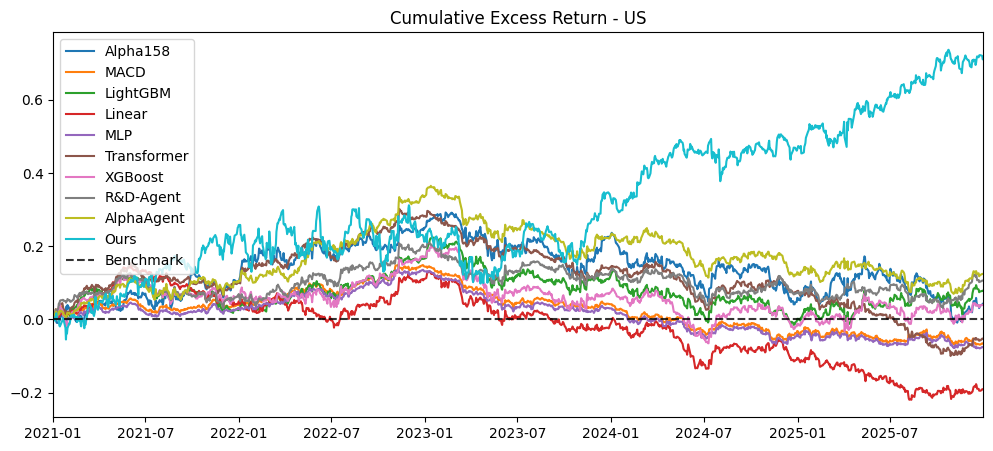

US perf_table


In [58]:
# ---- Draw CN/US plots ----
from IPython.display import display

out_cn = _plot_set(label_to_pkl_cn, "CN")
perf_table_cn = out_cn["perf_table"] if out_cn else pd.DataFrame()
print(perf_table_cn)

print('CN perf_table')
if len(perf_table_cn) == 0:
    display(pd.DataFrame(columns=['label','AR','IR','MDD','CR','mean','std']))
# else:
    # display(perf_table_cn[['label','AR','IR','MDD','CR','mean','std']])

out_us = _plot_set(label_to_pkl_us, "US")
perf_table_us = out_us["perf_table"] if out_us else pd.DataFrame()

print('US perf_table')
if len(perf_table_us) == 0:
    display(pd.DataFrame(columns=['label','AR','IR','MDD','CR','mean','std']))
# else:
#     display(perf_table_us[['label','AR','IR','MDD','CR','mean','std']])


In [59]:
perf_table_cn.columns


Index(['label', 'AR', 'IR', 'MDD', 'mean', 'std', 'CR'], dtype='object')

In [60]:
perf_table_cn.head()


,label,AR,IR,MDD,mean,std,CR
0,Alpha158,0.005073,0.037752,-0.337754,0.000021,0.008710,0.025790
1,MACD,0.059146,0.619587,-0.205418,0.000249,0.006188,0.300699
2,LightGBM,0.005789,0.070252,-0.164170,0.000024,0.005342,0.029434
3,Linear,0.005372,0.063072,-0.197551,0.000023,0.005521,0.027310
4,MLP,0.009358,0.117366,-0.186664,0.000039,0.005168,0.047574
